In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

 AI_TRACEFINDER    'Copy of 108.pdf'   Flatfield		 Objective1
'Colab Notebooks'   Fees	       flatfield_residuals.pkl	 Originals


In [ ]:
import os
dataset_path = "/content/drive/MyDrive/AI_TRACEFINDER"
# List main folders
print("Main folders:", os.listdir(dataset_path))

Main folders: ['Flatfield', 'Originals', 'TraceFinder_References', 'Official', 'Wikipedia', 'Tampered images', 'official_wiki_residuals.pkl']


Milestone 1 — Dataset collection and preprocessing

Mounts Google Drive at /content/drive to access the AI_TRACEFINDER dataset.

Recursively traverses the AI_TRACEFINDER directory and prints each folder name with the count of files directly inside it.

Tracks and accumulates file counts for each top-level category (e.g., Flatfield, Official, Wikipedia, Tampered images).

Prints a hierarchical view with indentation showing subfolders under each main folder.

After traversal, prints a summary table of total files per main folder.

Computes and displays a grand total of all files counted across the Objective1 tree.



EDA on folders

In [ ]:
import os
from google.colab import drive

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive', force_remount=False)

main_counts = {}  # dictionary to store counts per main folder

def print_tree_counts(path, indent="", top_level=None):
    global main_counts
    items = sorted(os.listdir(path))
    file_count = sum([1 for i in items if os.path.isfile(os.path.join(path, i))])
    print(f"{indent}📁 {os.path.basename(path)}/ ({file_count} files)")

    # track counts for top-level main folders
    if top_level is not None:
        main_counts[top_level] = main_counts.get(top_level, 0) + file_count

    for item in items:
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            # pass top_level = current main folder
            if indent == "":  # first level (Flatfield, Official, etc.)
                print_tree_counts(item_path, indent + "    ", top_level=item)
            else:
                print_tree_counts(item_path, indent + "    ", top_level=top_level)

# ---- Run on your dataset ----
dataset_path = "/content/drive/MyDrive/AI_TRACEFINDER"
print_tree_counts(dataset_path)

# ---- Print main folder totals ----
print("\n📊 Total files per main folder:")
for folder, count in main_counts.items():
    print(f"   {folder}: {count} files")

print(f"\n✅ Grand Total: {sum(main_counts.values())} files")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 AI_TRACEFINDER/ (1 files)
    📁 Flatfield/ (0 files)
        📁 Canon120-1/ (2 files)
        📁 Canon120-2/ (2 files)
        📁 Canon220/ (2 files)
        📁 Canon9000-1/ (2 files)
        📁 Canon9000-2/ (2 files)
        📁 EpsonV370-1/ (2 files)
        📁 EpsonV370-2/ (2 files)
        📁 EpsonV39-1/ (3 files)
        📁 EpsonV39-2/ (2 files)
        📁 EpsonV550/ (2 files)
        📁 HP/ (2 files)
    📁 Official/ (0 files)
        📁 Canon120-1/ (0 files)
            📁 150/ (100 files)
            📁 300/ (100 files)
        📁 Canon120-2/ (0 files)
            📁 150/ (100 files)
            📁 300/ (100 files)
        📁 Canon220/ (0 files)
            📁 150/ (100 files)
            📁 300/ (100 files)
        📁 Canon9000-1/ (0 files)
            📁 150/ (100 files)
            📁 300/ (100 files)
        📁 Canon9000-2/ (0 files)
            📁 150/ (100 files)
      

Mounts Google Drive and prepares access to the dataset within /content/drive/MyDrive.

Auto-discovers the Flatfield directory anywhere under MyDrive using a case-insensitive search.

Sets output path to save preprocessed residuals as flatfield_residuals.pkl alongside the Flatfield parent folder.

Imports denoisers (Wiener and wavelet), defaulting to Wiener; installs scikit-image on demand for wavelet.

Defines a preprocessing routine: read image, convert to grayscale, resize to 256×256, normalize to , denoise, and compute residual = image − denoised.

Iterates all scanners and valid image files in Flatfield, skips hidden/metadata files (e.g., ._), and accumulates residuals per scanner.

Saves a dictionary {scanner: [residual arrays]} to flatfield_residuals.pkl for downstream fingerprint extraction.

Prints a summary showing how many scanners and images were successfully processed, plus example scanner keys.




//Myexplanation
This code preprocesses the Flatfield dataset and extracts residual noise patterns from each scanned image.

Flatfield images are blank pages scanned by different scanners. Because they contain no document content, they are ideal for capturing the scanner’s hardware noise pattern, which is later used to identify the scanner source.

Mount Google Drive
Connect Google Drive to Google Colab to access the dataset.

Locate the Flatfield Folder
Automatically search and find the folder containing flatfield images in the Drive.

Load Required Libraries
Import libraries such as OpenCV, NumPy, SciPy, and scikit-image for image processing.

Read Each Image
Load the flatfield images from the scanner folders.

Convert Image to Grayscale
Remove color information so only intensity values remain.

Resize the Image
Resize every image to 256 × 256 so that all images have the same size.

Normalize Pixel Values
Convert pixel values from 0–255 to 0–1 for easier processing.

Apply Denoising Filter
Use Wavelet or Wiener filter to remove large structures from the image.

Extract Residual Noise
Compute the residual by subtracting the denoised image from the original image:
Residual = Original Image − Denoised Image

Store Residual Images
Save the residual noise patterns for each scanner in a dictionary.

Save the Processed Data
Store all residual images in a file called
flatfield_residuals.pkl

Print Summary
Display the number of scanners and total images processed.

In [ ]:
# ==============================
# STEP 2A: Preprocess Flatfield -> Save residuals (flatfield_residuals.pkl)
# ==============================

# 0) Mount drive
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os, pickle, cv2, numpy as np
from tqdm import tqdm

# ---------------------------
# 1) Auto-locate Flatfield folder
# ---------------------------
def find_flatfield(base="/content/drive/MyDrive"):
    found = []
    for root, dirs, files in os.walk(base):
        for d in dirs:
            if d.lower() == "flatfield":   # case-insensitive search
                found.append(os.path.join(root, d))
    return found

flatfield_paths = find_flatfield("/content/drive/MyDrive")
if not flatfield_paths:
    raise FileNotFoundError("❌ No 'Flatfield' folder found in your Drive. Please check dataset upload.")
else:
    FLATFIELD_DIR = flatfield_paths[0]  # take the first match
    BASE = os.path.dirname(FLATFIELD_DIR)
    OUTPUT_PKL = os.path.join(BASE, "flatfield_residuals.pkl")
    print("✅ Found Flatfield folder:", FLATFIELD_DIR)
    print("Will save residuals to:", OUTPUT_PKL)

# ---------------------------
# 2) Import denoising filters
# ---------------------------
try:
    from skimage.restoration import denoise_wavelet
except Exception:
    !pip install scikit-image
    from skimage.restoration import denoise_wavelet

from scipy.signal import wiener as scipy_wiener

# ---------------------------
# 3) Parameters
# ---------------------------
IMG_SIZE = (256, 256)      # resize target
DENOISE_METHOD = "wavelet"  # "wiener" or "wavelet"

# ---------------------------
# 4) Preprocess function
# ---------------------------
def preprocess_image_residual(path, img_size=IMG_SIZE, method="wiener"):
    """Read image -> grayscale -> resize -> normalize -> denoise -> return residual."""
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return None
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, img_size, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0
    if method == "wiener":
        den = scipy_wiener(img, mysize=(5,5))
    else:
        den = denoise_wavelet(img, channel_axis=None, rescale_sigma=True)
    return (img - den).astype(np.float32)

# ---------------------------
# 5) Process all Flatfield images
# ---------------------------
flatfield_residuals = {}
scanners = sorted(os.listdir(FLATFIELD_DIR))

for scanner in tqdm(scanners, desc="Scanners"):
    scanner_dir = os.path.join(FLATFIELD_DIR, scanner)
    if not os.path.isdir(scanner_dir):
        continue

    residuals = []
    for fname in sorted(os.listdir(scanner_dir)):
        if fname.startswith("._"):
            continue
        if not fname.lower().endswith((".tif", ".tiff", ".png", ".jpg", ".jpeg")):
            continue
        fpath = os.path.join(scanner_dir, fname)
        try:
            res = preprocess_image_residual(fpath, IMG_SIZE, DENOISE_METHOD)
            if res is not None:
                residuals.append(res)
        except Exception as e:
            print(f"⚠️ Failed on {fpath}: {e}")

    if residuals:
        flatfield_residuals[scanner] = residuals
    else:
        print(f"⚠️ No valid images for scanner: {scanner}")

# ---------------------------
# 6) Save results
# ---------------------------
with open(OUTPUT_PKL, "wb") as f:
    pickle.dump(flatfield_residuals, f)

# ---------------------------
# 7) Summary
# ---------------------------
total_scanners = len(flatfield_residuals)
total_images = sum(len(v) for v in flatfield_residuals.values())
print(f"\n✅ Done. Saved residuals for {total_scanners} scanners, {total_images} images.")
print("Example scanners:", list(flatfield_residuals.keys())[:5])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Found Flatfield folder: /content/drive/MyDrive/Flatfield
Will save residuals to: /content/drive/MyDrive/flatfield_residuals.pkl


Scanners: 100%|██████████| 11/11 [00:48<00:00,  4.44s/it]



✅ Done. Saved residuals for 11 scanners, 22 images.
Example scanners: ['Canon120-1', 'Canon120-2', 'Canon220', 'Canon9000-1', 'Canon9000-2']


In [ ]:
import pickle
import os

path = "/content/drive/MyDrive/flatfield_residuals.pkl" # Corrected path to actual save location

if os.path.exists(path):
    print("Residual file created successfully.")

    with open(path, "rb") as f:
        data = pickle.load(f)

    print("Number of scanners processed:", len(data))

    for scanner in data:
        print(scanner, "->", len(data[scanner]), "residual images")

    # check sample residual
    first_scanner = list(data.keys())[0]
    sample = data[first_scanner][0]

    print("Sample residual shape:", sample.shape)
    print("Pixel value range:", sample.min(), "to", sample.max())

else:
    print("Residual file not found. Preprocessing may have failed.")

Residual file created successfully.
Number of scanners processed: 11
Canon120-1 -> 2 residual images
Canon120-2 -> 2 residual images
Canon220 -> 2 residual images
Canon9000-1 -> 2 residual images
Canon9000-2 -> 2 residual images
EpsonV370-1 -> 2 residual images
EpsonV370-2 -> 2 residual images
EpsonV39-1 -> 2 residual images
EpsonV39-2 -> 2 residual images
EpsonV550 -> 2 residual images
HP -> 2 residual images
Sample residual shape: (256, 256)
Pixel value range: -0.019584715 to 2.3126602e-05


Defines a fast residual-preprocessing pipeline for Official and Wikipedia datasets using grayscale, 256×256 resize, normalization, and Haar wavelet denoising.

Implements denoise_wavelet by zeroing DWT detail coefficients (cH, cV, cD) and reconstructing, then computes residual = image − denoised.

Processes data hierarchically by scanner and DPI (150, 300), preserving structure in an output dictionary.

Uses ThreadPoolExecutor to parallelize per-file preprocessing for speed on Colab.

Filters valid image extensions (.tif, .tiff, .jpg, .jpeg, .png) and skips non-directories safely.

Saves all residuals into official_wiki_residuals.pkl with separate entries for Official and Wikipedia and for each scanner/DPI.



Step 2B preprocesses scanned document images by removing document content and extracting residual noise patterns that represent the scanner’s hardware fingerprint.
When a document is scanned, the image contains two things:

**Document content**

text shapes layout

**Scanner noise**

tiny hardware patterns

sensor imperfections

illumination artifacts

**Residual is calculated as**:

Residual = Original Image − Denoised Image

**Original Image** → scanned document

**Denoised Image** → image with smooth content (text/layout removed)

**Residual** → leftover noise pattern

In [ ]:
# ==============================
# STEP 2B: Faster Preprocessing (Official + Wikipedia, with Parallelization)
# ==============================
import os, cv2, numpy as np, pickle
from tqdm import tqdm
import pywt
from concurrent.futures import ThreadPoolExecutor, as_completed

# Paths
# Corrected paths to point to the actual location of the datasets
OFFICIAL_DIR = "/content/drive/MyDrive/AI_TRACEFINDER/Official"
WIKI_DIR = "/content/drive/MyDrive/AI_TRACEFINDER/Wikipedia"
OUT_PATH = "/content/drive/MyDrive/AI_TRACEFINDER/official_wiki_residuals.pkl"

# ---------------------------
# Preprocessing helpers
# ---------------------------
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img

def resize_to(img, size=(256,256)):
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

def normalize_img(img):
    return img.astype(np.float32) / 255.0

def denoise_wavelet(img):
    coeffs = pywt.dwt2(img, 'haar')
    cA, (cH, cV, cD) = coeffs
    # Zero out detail coefficients for denoising
    cH[:] = 0; cV[:] = 0; cD[:] = 0
    return pywt.idwt2((cA,(cH,cV,cD)), 'haar')

def compute_residual(img):
    denoised = denoise_wavelet(img)
    return img - denoised

def process_single_image(fpath):
    """Preprocess one image and return residual."""
    img = cv2.imread(fpath, cv2.IMREAD_COLOR)
    if img is None:
        return None
    gray = to_gray(img)
    gray = resize_to(gray, (256,256))
    gray = normalize_img(gray)
    return compute_residual(gray)

# ---------------------------
# Dataset Processing
# ---------------------------
def process_dataset(base_dir, dataset_name, residuals_dict):
    print(f"🔄 Preprocessing {dataset_name} images...")

    for scanner in tqdm(os.listdir(base_dir)):
        scanner_path = os.path.join(base_dir, scanner)
        if not os.path.isdir(scanner_path):
            continue

        residuals_dict[dataset_name][scanner] = {}

        for dpi in os.listdir(scanner_path):   # 150, 300
            dpi_path = os.path.join(scanner_path, dpi)
            if not os.path.isdir(dpi_path):
                continue

            files = [os.path.join(dpi_path, f) for f in os.listdir(dpi_path)
                     if f.lower().endswith(('.tif','.tiff','.jpg','.jpeg','.png'))]

            dpi_residuals = []
            # Parallel processing
            with ThreadPoolExecutor(max_workers=8) as executor:  # adjust workers based on Colab
                futures = [executor.submit(process_single_image, f) for f in files]
                for fut in as_completed(futures):
                    res = fut.result()
                    if res is not None:
                        dpi_residuals.append(res)

            residuals_dict[dataset_name][scanner][dpi] = dpi_residuals

# ---------------------------
# Main Execution
# ---------------------------
residuals_dict = {"Official": {}, "Wikipedia": {}}

process_dataset(OFFICIAL_DIR, "Official", residuals_dict)
process_dataset(WIKI_DIR, "Wikipedia", residuals_dict)

with open(OUT_PATH, "wb") as f:
    pickle.dump(residuals_dict, f)

print(f"✅ Saved Official+Wiki residuals (150 & 300 separately) to {OUT_PATH}")

🔄 Preprocessing Official images...


100%|██████████| 11/11 [09:56<00:00, 54.19s/it]


🔄 Preprocessing Wikipedia images...


100%|██████████| 11/11 [13:01<00:00, 71.01s/it]


✅ Saved Official+Wiki residuals (150 & 300 separately) to /content/drive/MyDrive/AI_TRACEFINDER/official_wiki_residuals.pkl


In [ ]:
import pickle
import os
import numpy as np

PATH = "/content/drive/MyDrive/AI_TRACEFINDER/official_wiki_residuals.pkl"

# 1. Check if file exists
if os.path.exists(PATH):
    print("✅ Preprocessed file found:", PATH)
else:
    print("❌ Preprocessed file not found. Preprocessing may have failed.")

# 2. Load the residual data
with open(PATH, "rb") as f:
    data = pickle.load(f)

print("\nDatasets available:", list(data.keys()))

total_images = 0

# 3. Print dataset structure
for dataset in data:
    print("\nDataset:", dataset)

    for scanner in data[dataset]:
        for dpi in data[dataset][scanner]:
            count = len(data[dataset][scanner][dpi])
            print(f"{scanner} | DPI {dpi} -> {count} residual images")
            total_images += count

print("\nTotal residual images:", total_images)

# 4. Check one sample residual
dataset = list(data.keys())[0]
scanner = list(data[dataset].keys())[0]
dpi = list(data[dataset][scanner].keys())[0]

sample = data[dataset][scanner][dpi][0]

print("\nSample residual shape:", sample.shape)
print("Pixel value range:", sample.min(), "to", sample.max())

✅ Preprocessed file found: /content/drive/MyDrive/AI_TRACEFINDER/official_wiki_residuals.pkl

Datasets available: ['Official', 'Wikipedia']

Dataset: Official
Canon120-1 | DPI 150 -> 100 residual images
Canon120-1 | DPI 300 -> 100 residual images
Canon220 | DPI 300 -> 100 residual images
Canon220 | DPI 150 -> 100 residual images
EpsonV370-2 | DPI 300 -> 100 residual images
EpsonV370-2 | DPI 150 -> 100 residual images
EpsonV370-1 | DPI 150 -> 100 residual images
EpsonV370-1 | DPI 300 -> 100 residual images
Canon9000-2 | DPI 150 -> 100 residual images
Canon9000-2 | DPI 300 -> 100 residual images
Canon120-2 | DPI 150 -> 100 residual images
Canon120-2 | DPI 300 -> 100 residual images
HP | DPI 300 -> 100 residual images
HP | DPI 150 -> 100 residual images
EpsonV39-2 | DPI 150 -> 100 residual images
EpsonV39-2 | DPI 300 -> 100 residual images
EpsonV550 | DPI 150 -> 100 residual images
EpsonV550 | DPI 300 -> 100 residual images
Canon9000-1 | DPI 150 -> 100 residual images
Canon9000-1 | DPI 30

Scans Official and Wikipedia roots, walking scanner and DPI subfolders to enumerate all images.

Filters files by common image extensions (.tif, .tiff, .png, .jpg, .jpeg) before recording entries.

Builds a rows list with four columns per image: dataset, scanner, dpi, and absolute file path.

Writes a CSV header and all rows to dataset_inventory.csv under Objective1.

Ensures the output directory exists and prints the save path plus total row count for verification.



This code scans the dataset folders and generates a CSV inventory containing dataset type, scanner name, DPI, and file path for every image, helping organize and manage the dataset for further processing.
3. Filter Image Files

It only selects valid image formats such as:
.tif
.tiff
.png
.jpg
.jpeg

This ensures only real images are included.

4.Store Image Information

For every image found, the code stores:

dataset name

scanner name

DPI

file path

All this information is stored in a list called rows.

In [ ]:
# ==============================
# INSERT A: Dataset inventory CSV (after Step 2B)
# ==============================
import os, csv

roots = [
  ("/content/drive/MyDrive/AI_TRACEFINDER/Official", "Official"),
  ("/content/drive/MyDrive/AI_TRACEFINDER/Wikipedia", "Wikipedia"),
]
rows = []
for root, ds in roots:
    if not os.path.isdir(root):
        continue
    for scanner in sorted(os.listdir(root)):
        sp = os.path.join(root, scanner)
        if not os.path.isdir(sp):
            continue
        for dpi in sorted(os.listdir(sp)):
            dp = os.path.join(sp, dpi)
            if not os.path.isdir(dp):
                continue
            for f in sorted(os.listdir(dp)):
                if f.lower().endswith(('.tif','.tiff','.png','.jpg','.jpeg')):
                    rows.append([ds, scanner, dpi, os.path.join(dp,f)])

out_csv = "/content/drive/MyDrive/AI_TRACEFINDER/dataset_inventory.csv"
os.makedirs(os.path.dirname(out_csv), exist_ok=True)
with open(out_csv, "w", newline="") as fh:
    w = csv.writer(fh)
    w.writerow(["dataset","scanner","dpi","path"])
    w.writerows(rows)

print("Wrote inventory:", out_csv, "| rows:", len(rows))


Wrote inventory: /content/drive/MyDrive/AI_TRACEFINDER/dataset_inventory.csv | rows: 4568


Loads precomputed Flatfield residuals from flatfield_residuals.pkl.

Computes a per-scanner fingerprint by averaging residual images to capture stable scanner-specific noise.

Stores all fingerprints in scanner_fingerprints.pkl for reuse in feature extraction and inference.

Creates a deterministic, sorted list of scanner keys (fp_keys) and saves it to fp_keys.npy.

Uses the saved key order later to ensure feature vectors align consistently across training and inference.



**Milestone 2 — Feature engineering and baselines**

In [ ]:
# ==============================
# STEP 3: Fingerprint Extraction (from Flatfields) + Save stable order
# ==============================
import pickle, numpy as np

# Paths
FLATFIELD_RESIDUALS_PATH = "/content/drive/MyDrive/flatfield_residuals.pkl"  # Corrected path from Step 2A
FP_OUT_PATH = "/content/drive/MyDrive/AI_TRACEFINDER/scanner_fingerprints.pkl"
ORDER_NPY   = "/content/drive/MyDrive/AI_TRACEFINDER/fp_keys.npy"

# ---------------------------
# Load residuals
# ---------------------------
with open(FLATFIELD_RESIDUALS_PATH, "rb") as f:
    flatfield_residuals = pickle.load(f)

# ---------------------------
# Compute fingerprint per scanner
# ---------------------------
scanner_fingerprints = {}
print("🔄 Computing fingerprints from Flatfields...")
for scanner, residuals in flatfield_residuals.items():
    if not residuals:
        continue
    stack = np.stack(residuals, axis=0)       # (num_images, H, W)
    fingerprint = np.mean(stack, axis=0)      # average residual
    scanner_fingerprints[scanner] = fingerprint

print(f"✅ Extracted {len(scanner_fingerprints)} scanner fingerprints.")

# ---------------------------
# Save fingerprints
# ---------------------------
with open(FP_OUT_PATH, "wb") as f:
    pickle.dump(scanner_fingerprints, f)
print(f"✅ Saved scanner fingerprints to {FP_OUT_PATH}")

# ---------------------------
# Save a stable, deterministic order for scanners
# ---------------------------
fp_keys = sorted(scanner_fingerprints.keys())
np.save(ORDER_NPY, np.array(fp_keys))
print("✅ Saved fp_keys.npy with order:", fp_keys)


🔄 Computing fingerprints from Flatfields...
✅ Extracted 11 scanner fingerprints.
✅ Saved scanner fingerprints to /content/drive/MyDrive/AI_TRACEFINDER/scanner_fingerprints.pkl
✅ Saved fp_keys.npy with order: ['Canon120-1', 'Canon120-2', 'Canon220', 'Canon9000-1', 'Canon9000-2', 'EpsonV370-1', 'EpsonV370-2', 'EpsonV39-1', 'EpsonV39-2', 'EpsonV550', 'HP']


This step generates a unique fingerprint for each scanner using the residual noise patterns obtained from the flatfield images in Step 2A.

Flatfield images contain mostly scanner noise, so they are useful for building the scanner’s hardware signature.
pickle → used to load and save processed data

numpy → used for numerical operations such as stacking and averaging images

FLATFIELD_RESIDUALS_PATH:	location of residual images created in Step 2A
FP_OUT_PATH	file: where scanner fingerprints will be saved
ORDER_NPY: file storing scanner names in a fixed order

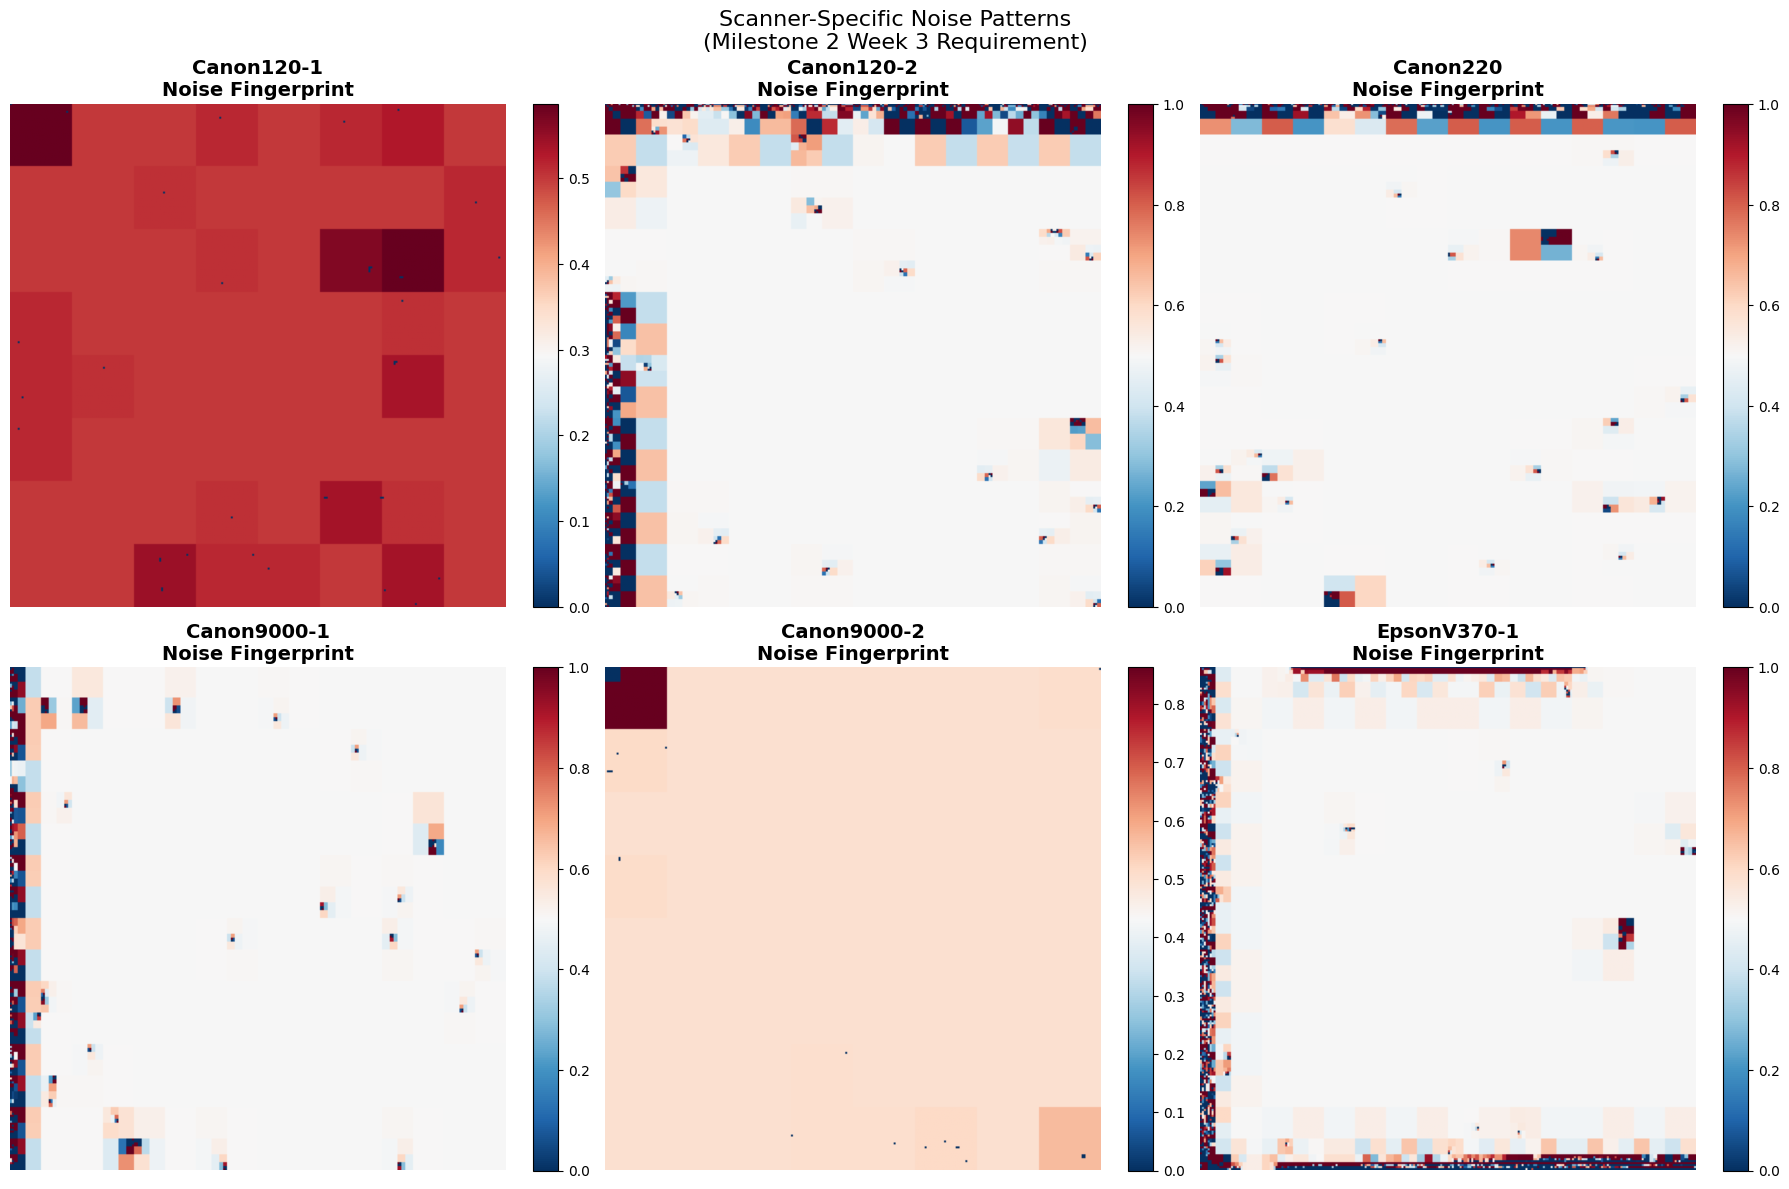

✅ Scanner noise visualization complete - Milestone 2 Week 3 ✅


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import pickle  # FIX: Add missing import
import os

def visualize_scanner_differences():
    """Visualize differences between scanner outputs (noise maps) - REQUIRED by Week 3"""

    with open("/content/drive/MyDrive/AI_TRACEFINDER/scanner_fingerprints.pkl", "rb") as f:
        scanner_fps = pickle.load(f)

    # Create noise pattern visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    scanners = list(scanner_fps.keys())[:6]

    for i, scanner in enumerate(scanners):
        fp = scanner_fps[scanner]

        # Enhance contrast for visualization
        fp_enhanced = (fp - fp.mean()) / (fp.std() + 1e-8) * 0.5 + 0.5
        fp_clipped = np.clip(fp_enhanced, 0, 1)

        im = axes[i].imshow(fp_clipped, cmap='RdBu_r', aspect='auto')
        axes[i].set_title(f'{scanner}\nNoise Fingerprint', fontsize=14, fontweight='bold')
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i], fraction=0.046)

    plt.suptitle('Scanner-Specific Noise Patterns\n(Milestone 2 Week 3 Requirement)', fontsize=16)
    plt.tight_layout()

    # Save plot
    os.makedirs('/content/drive/MyDrive/AI_TRACEFINDER/metrics', exist_ok=True)
    plt.savefig('/content/drive/MyDrive/AI_TRACEFINDER/metrics/scanner_noise_maps.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    print("✅ Scanner noise visualization complete - Milestone 2 Week 3 ✅")

# Run visualization
visualize_scanner_differences()


Prints a hierarchical tree of Objective1 with indentation for subfolders.

Lists subfolders at each level and recurses into them.

Shows only a small sample of files per folder (default 3) for quick inspection.

Indicates when more files exist in a folder beyond the shown sample.

In [ ]:
import os

base_dir = "/content/drive/MyDrive/AI_TRACEFINDER"

def list_folders(path, indent=0, file_limit=3):
    # Print current folder name
    print(" " * indent + f"📂 {os.path.basename(path)}/")

    try:
        items = os.listdir(path)
    except PermissionError:
        return

    subfolders = [f for f in items if os.path.isdir(os.path.join(path, f))]
    files = [f for f in items if os.path.isfile(os.path.join(path, f))]

    # Print subfolders
    if subfolders:
        print(" " * (indent + 2) + "Subfolders:", subfolders)
        for sf in subfolders:
            list_folders(os.path.join(path, sf), indent + 4, file_limit)

    # Print only sample files
    if files:
        sample_files = files[:file_limit]
        print(" " * (indent + 2) + "Files (sample):", sample_files)
        if len(files) > file_limit:
            print(" " * (indent + 2) + f"... (+{len(files) - file_limit} more)")

# Run it
list_folders(base_dir)


📂 AI_TRACEFINDER/
  Subfolders: ['Flatfield', 'Originals', 'TraceFinder_References', 'Official', 'Wikipedia', 'Tampered images', 'metrics']
    📂 Flatfield/
      Subfolders: ['Canon120-1', 'EpsonV39-1', 'Canon120-2', 'Canon220', 'HP', 'EpsonV370-2', 'EpsonV39-2', 'Canon9000-1', 'EpsonV550', 'EpsonV370-1', 'Canon9000-2']
        📂 Canon120-1/
          Files (sample): ['300.tif', '150.tif']
        📂 EpsonV39-1/
          Files (sample): ['300.tif', '150.tif', '._150.tif']
        📂 Canon120-2/
          Files (sample): ['300.tif', '150.tif']
        📂 Canon220/
          Files (sample): ['300.tif', '150.tif']
        📂 HP/
          Files (sample): ['300.tif', '150.tif']
        📂 EpsonV370-2/
          Files (sample): ['300.tif', '150.tif']
        📂 EpsonV39-2/
          Files (sample): ['300.tif', '150.tif']
        📂 Canon9000-1/
          Files (sample): ['300.tif', '150.tif']
        📂 EpsonV550/
          Files (sample): ['300.tif', '150.tif']
        📂 EpsonV370-1/
          F

Loads scanner fingerprints and a fixed scanner key order to ensure consistent feature vector layout.

Defines corr2d to compute zero-mean normalized cross-correlation (ZNCC) between an image residual and each fingerprint.

Loads precomputed residuals for Official and Wikipedia and iterates by scanner and DPI.

For every residual image, builds a feature vector as correlations to all fingerprints in fp_keys order and records the corresponding scanner label.

Saves features and labels to features.pkl and prints the resulting matrix shape.

In [ ]:
# ==============================
# STEP 4 : Feature Extraction using existing residuals + stable order
# ==============================
import pickle, numpy as np
from tqdm import tqdm

# Paths
RES_PATH   = "/content/drive/MyDrive/AI_TRACEFINDER/official_wiki_residuals.pkl"
FP_PATH    = "/content/drive/MyDrive/AI_TRACEFINDER/scanner_fingerprints.pkl"
ORDER_NPY  = "/content/drive/MyDrive/AI_TRACEFINDER/fp_keys.npy"
OUT_PATH   = "/content/drive/MyDrive/AI_TRACEFINDER/features.pkl"

# Load fingerprints and fixed order
with open(FP_PATH, "rb") as f:
    scanner_fps = pickle.load(f)
fp_keys = np.load(ORDER_NPY, allow_pickle=True).tolist()
print("✅ Loaded fingerprints and key order. Keys:", fp_keys)

# Helper: normalized cross-correlation (zero-mean cosine similarity)
def corr2d(a, b):
    a = a.astype(np.float32).ravel()
    b = b.astype(np.float32).ravel()
    a -= a.mean()
    b -= b.mean()
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    return float((a @ b) / denom) if denom != 0 else 0.0
# ZNCC equals the dot product of zero-mean, unit-norm vectors, i.e., cosine similarity in L2 space. [web:188][web:189][web:169]

# Load residuals (already precomputed; do not preprocess again)
with open(RES_PATH, "rb") as f:
    residuals_dict = pickle.load(f)
print("✅ Loaded residuals for datasets:", list(residuals_dict.keys()))

# Build features in the exact fp_keys order
features, labels = [], []
for dataset_name in ["Official", "Wikipedia"]:
    print(f"🔄 Computing features for {dataset_name} ...")
    for scanner, dpi_dict in tqdm(residuals_dict[dataset_name].items()):
        for dpi, res_list in dpi_dict.items():
            for res in res_list:
                vec = [corr2d(res, scanner_fps[k]) for k in fp_keys]
                features.append(vec)
                labels.append(scanner)

# Save features + labels
with open(OUT_PATH, "wb") as f:
    pickle.dump({"features": features, "labels": labels}, f)
print(f"✅ Saved features + labels to {OUT_PATH}")
print("Shape:", (len(features), len(features[0]) if features else 0))


✅ Loaded fingerprints and key order. Keys: ['Canon120-1', 'Canon120-2', 'Canon220', 'Canon9000-1', 'Canon9000-2', 'EpsonV370-1', 'EpsonV370-2', 'EpsonV39-1', 'EpsonV39-2', 'EpsonV550', 'HP']
✅ Loaded residuals for datasets: ['Official', 'Wikipedia']
🔄 Computing features for Official ...


100%|██████████| 11/11 [00:07<00:00,  1.39it/s]


🔄 Computing features for Wikipedia ...


100%|██████████| 11/11 [00:08<00:00,  1.36it/s]

✅ Saved features + labels to /content/drive/MyDrive/AI_TRACEFINDER/features.pkl
Shape: (4568, 11)


RES_PATH	residual images from Step 2B
FP_PATH	scanner fingerprints from Step 3
ORDER_NPY	fixed order of scanners
OUT_PATH	location where extracted features will be saved
Step 4 extracts numerical features by computing correlation scores between residual images and scanner fingerprints, converting each image into a feature vector used for scanner classification.

In [ ]:
import pickle

path = "/content/drive/MyDrive/AI_TRACEFINDER/features.pkl"

with open(path, "rb") as f:
    data = pickle.load(f)

print("Total samples:", len(data["features"]))
print("Feature length:", len(data["features"][0]))
print("First feature vector:", data["features"][0])
print("First label:", data["labels"][0])

Total samples: 4568
Feature length: 11
First feature vector: [-0.003866572631523013, 7.663751603104174e-05, 0.0010314814280718565, 0.002176642883569002, 4.899275882053189e-05, -0.0005724403890781105, 0.001103935413993895, 0.002785136690363288, -0.0006725659477524459, -0.0010187751613557339, 0.005854904185980558]
First label: Canon120-1


In [ ]:
# ==============================
# STEP 4B: Enhanced Feature Extraction (FFT + LBP + Texture)
# ==============================
import pickle, numpy as np
from tqdm import tqdm
from skimage.feature import local_binary_pattern
from scipy import ndimage
from scipy.fft import fft2, fftshift
import matplotlib.pyplot as plt

# Load existing residuals
RES_PATH = "/content/drive/MyDrive/AI_TRACEFINDER/official_wiki_residuals.pkl"
with open(RES_PATH, "rb") as f:
    residuals_dict = pickle.load(f)

def extract_enhanced_features(residual):
    """Extract comprehensive features: PRNU correlation + FFT + LBP + Texture"""

    # 1. FFT Features (frequency domain)
    fft_img = np.abs(fft2(residual))
    fft_img = fftshift(fft_img)

    # Extract frequency bands
    h, w = fft_img.shape
    center_h, center_w = h//2, w//2

    # Low, mid, high frequency energy
    low_freq = np.mean(fft_img[center_h-20:center_h+20, center_w-20:center_w+20])
    mid_freq = np.mean(fft_img[center_h-60:center_h+60, center_w-60:center_w+60]) - low_freq
    high_freq = np.mean(fft_img) - low_freq - mid_freq

    # 2. LBP Texture Features
    lbp = local_binary_pattern(residual, P=24, R=3, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=26, range=(0, 25), density=True)

    # 3. Statistical Texture Features
    grad_x = ndimage.sobel(residual, axis=1)
    grad_y = ndimage.sobel(residual, axis=0)
    gradient_mag = np.sqrt(grad_x**2 + grad_y**2)

    texture_features = [
        np.std(residual),           # Standard deviation
        np.mean(np.abs(residual)),  # Mean absolute value
        np.std(gradient_mag),       # Gradient variation
        np.mean(gradient_mag),      # Edge strength
    ]

    return [low_freq, mid_freq, high_freq] + lbp_hist.tolist() + texture_features

# Extract enhanced features for all images
print("🔄 Extracting enhanced features (FFT + LBP + Texture)...")
enhanced_features, enhanced_labels = [], []

for dataset_name in ["Official", "Wikipedia"]:
    print(f"Processing {dataset_name}...")
    for scanner, dpi_dict in tqdm(residuals_dict[dataset_name].items()):
        for dpi, res_list in dpi_dict.items():
            for res in res_list:
                feat = extract_enhanced_features(res)
                enhanced_features.append(feat)
                enhanced_labels.append(scanner)

# Save enhanced features
ENHANCED_OUT = "/content/drive/MyDrive/AI_TRACEFINDER/enhanced_features.pkl"
with open(ENHANCED_OUT, "wb") as f:
    pickle.dump({"features": enhanced_features, "labels": enhanced_labels}, f)

print(f"✅ Enhanced features shape: {len(enhanced_features)} x {len(enhanced_features[0])}")
print(f"✅ Saved to {ENHANCED_OUT}")


🔄 Extracting enhanced features (FFT + LBP + Texture)...
Processing Official...


  0%|          | 0/11 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 11/11 [02:06<00:00, 11.48s/it]


Processing Wikipedia...


100%|██████████| 11/11 [02:31<00:00, 13.78s/it]

✅ Enhanced features shape: 4568 x 33
✅ Saved to /content/drive/MyDrive/AI_TRACEFINDER/enhanced_features.pkl


This step extracts advanced features from the residual images to improve scanner identification.
Instead of using only correlation, the code analyzes frequency patterns, textures, and statistical properties of the residual noise.

These features capture different characteristics of the scanner noise.
FFT Features (Frequency Domain)
fft_img = fft2(residual)
fft_img = fftshift(fft_img)

FFT (Fast Fourier Transform) converts the image into the frequency domain.

It analyzes how noise patterns are distributed across frequencies.

The code calculates:

Low-frequency energy

Mid-frequency energy

High-frequency energy

These represent different noise characteristics of the scanner.

5. LBP Texture Features
lbp = local_binary_pattern(residual, P=24, R=3)

LBP (Local Binary Pattern) captures texture patterns.

It analyzes local pixel relationships and produces a histogram of texture patterns.

These patterns can help distinguish scanners.

6. Statistical Texture Features

The code computes statistical measures such as:

Standard deviation of residual

Mean absolute residual

Gradient variation

Average edge strength

These features describe the overall texture and variation of scanner noise.

7. Combine All Features

The final feature vector is created by combining:

FFT features
+ LBP histogram
+ statistical texture features

Example feature vector:

[low_freq, mid_freq, high_freq, ...LBP histogram..., std, mean_abs, grad_std, grad_mean]

Each image becomes a numerical feature vector.

8. Extract Features for All Images

The code loops through:

Official dataset
Wikipedia dataset
Scanner folders
DPI folders
Residual images

For each residual image:

features are extracted

the scanner label is stored

Two lists are created:

enhanced_features
enhanced_labels
Step 4B extracts enhanced features from residual images using FFT frequency analysis, LBP texture patterns, and statistical texture measures to create a comprehensive feature representation for scanner identification.

🔄 Creating PCA visualization...


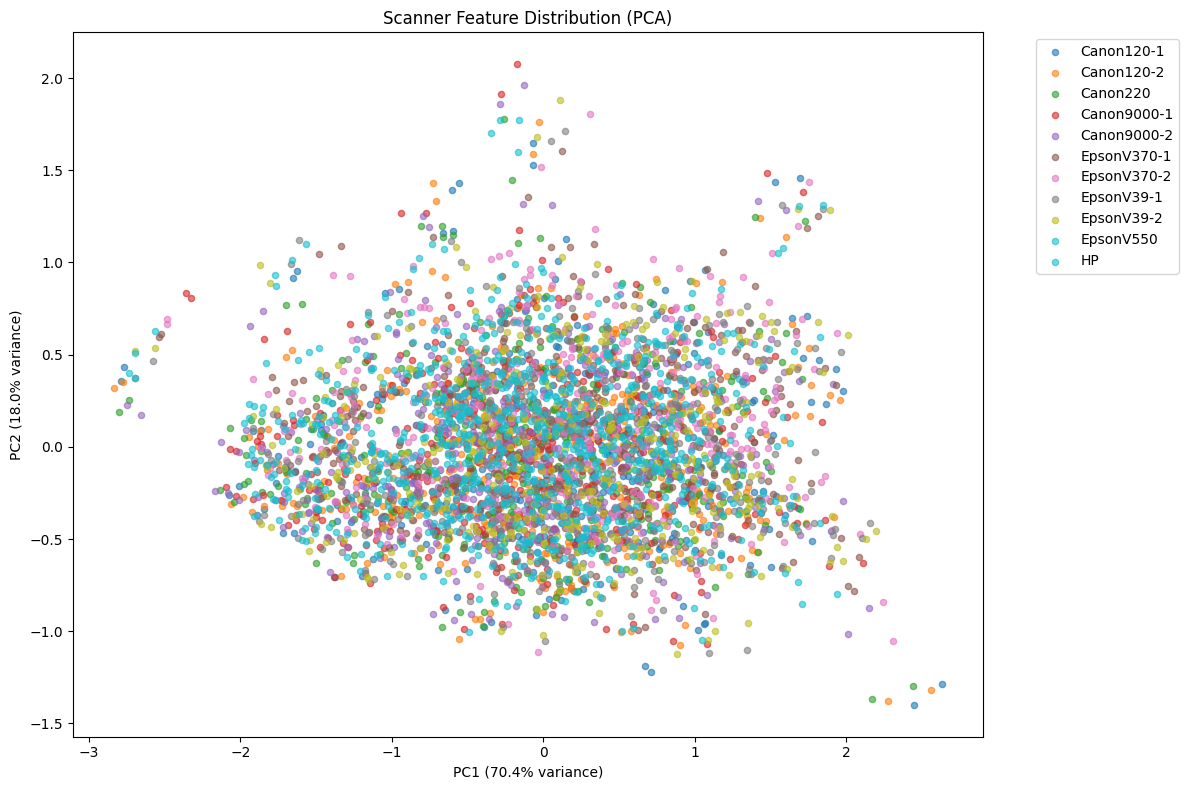

🔄 Creating t-SNE visualization...


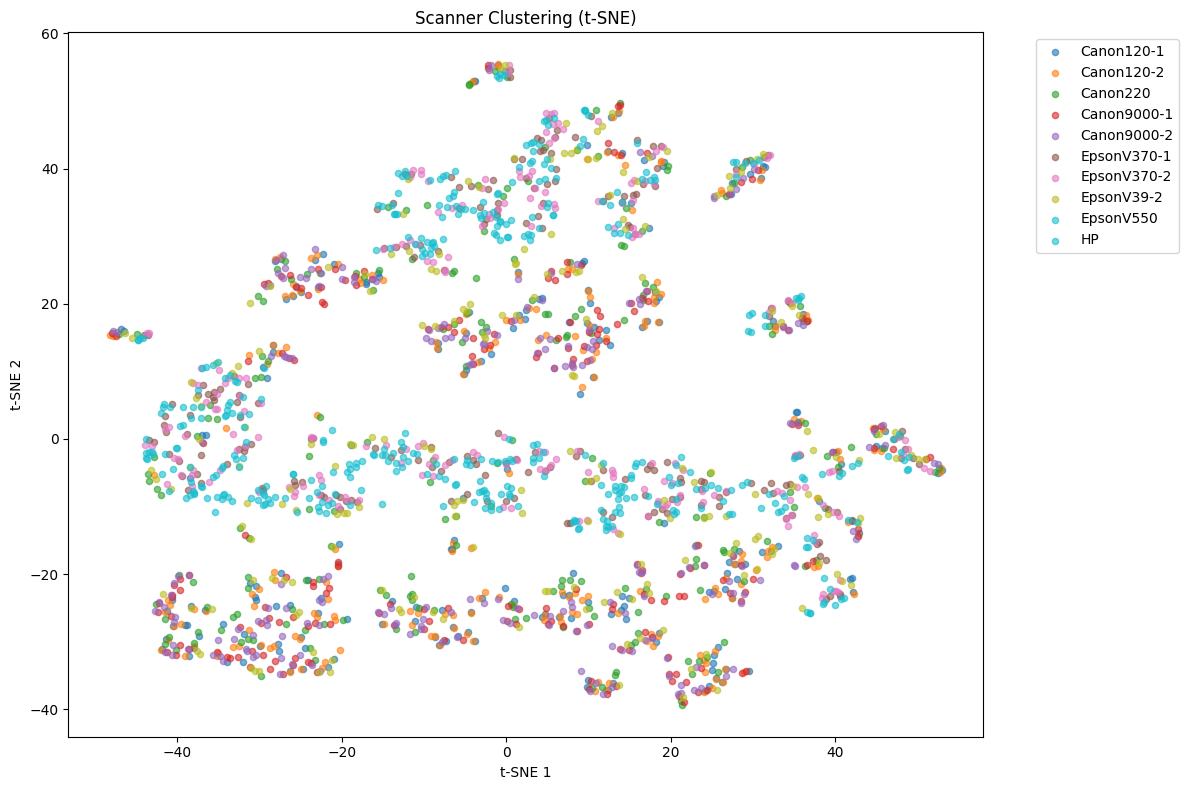

🔄 Computing feature correlations...


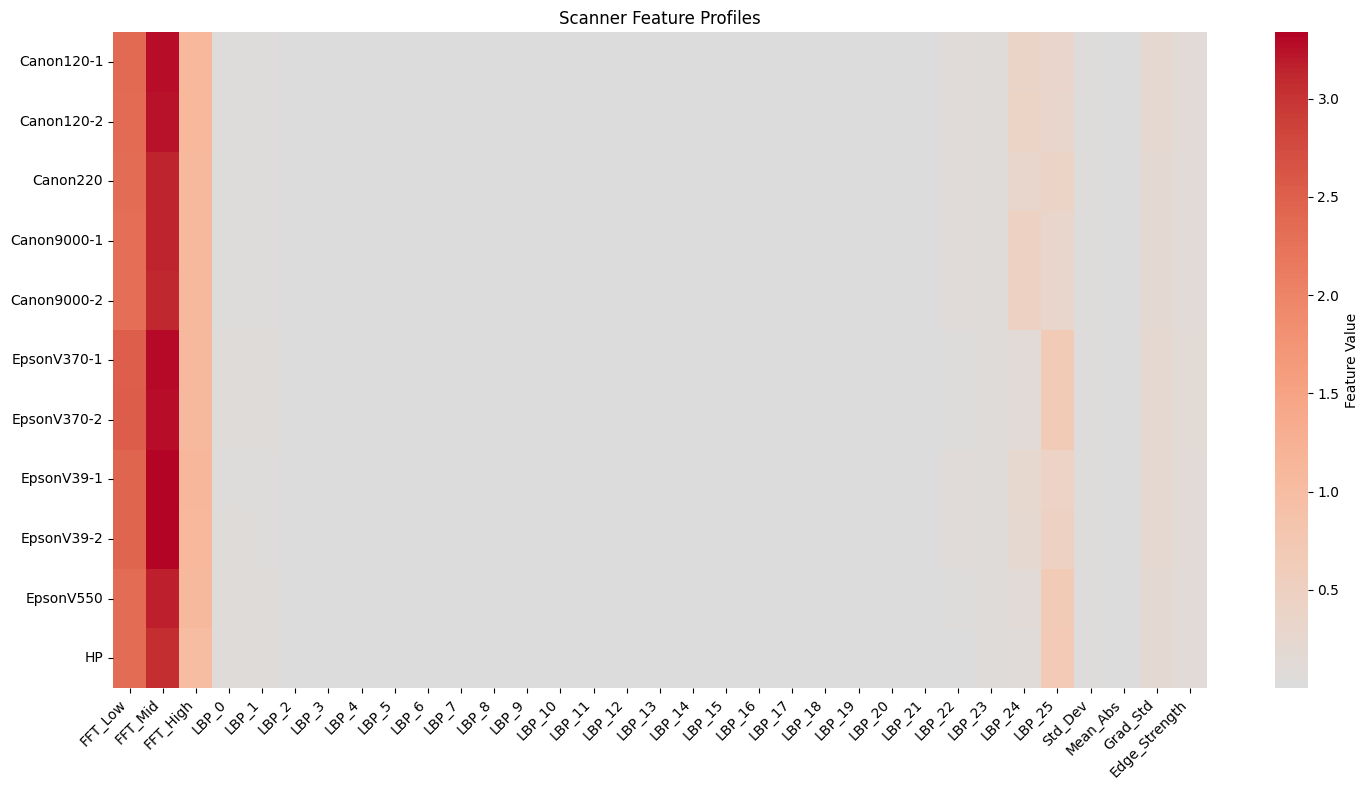

✅ Visualizations saved to /content/drive/MyDrive/AI_TRACEFINDER/


In [ ]:
# ==============================
# STEP 4C: Feature Visualization & Scanner Differences
# ==============================
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Load enhanced features
with open("/content/drive/MyDrive/AI_TRACEFINDER/enhanced_features.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
y = np.array(data["labels"])

# 1. PCA Visualization
print("🔄 Creating PCA visualization...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
scanners = np.unique(y)
colors = plt.cm.tab10(np.linspace(0, 1, len(scanners)))

for i, scanner in enumerate(scanners):
    mask = y == scanner
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=[colors[i]], label=scanner, alpha=0.6, s=20)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Scanner Feature Distribution (PCA)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_TRACEFINDER/pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. t-SNE Visualization
print("🔄 Creating t-SNE visualization...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X[:2000])  # Subset for speed
y_subset = y[:2000]

plt.figure(figsize=(12, 8))
for i, scanner in enumerate(scanners):
    mask = y_subset == scanner
    if np.sum(mask) > 0:
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=[colors[i]], label=scanner, alpha=0.6, s=20)

plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('Scanner Clustering (t-SNE)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_TRACEFINDER/tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Feature Importance Heatmap
print("🔄 Computing feature correlations...")
feature_names = (['FFT_Low', 'FFT_Mid', 'FFT_High'] +
                [f'LBP_{i}' for i in range(26)] +
                ['Std_Dev', 'Mean_Abs', 'Grad_Std', 'Edge_Strength'])

# Compute mean features per scanner
scanner_profiles = {}
for scanner in scanners:
    mask = y == scanner
    scanner_profiles[scanner] = np.mean(X[mask], axis=0)

# Create heatmap data
heatmap_data = np.array([scanner_profiles[s] for s in scanners])

plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data,
            xticklabels=feature_names,
            yticklabels=scanners,
            cmap='coolwarm', center=0,
            cbar_kws={'label': 'Feature Value'})
plt.title('Scanner Feature Profiles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/AI_TRACEFINDER/feature_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved to /content/drive/MyDrive/AI_TRACEFINDER/")


Step 4C: Feature Visualization & Scanner Differences

This step visualizes the extracted features to understand how different scanners behave and whether the features can distinguish scanners clearly.

Load enhanced features generated from the previous step.

Apply PCA (Principal Component Analysis) to reduce feature dimensions and visualize scanner distribution in 2D.

Apply t-SNE to visualize clustering of images from different scanners.

Create a heatmap to compare average feature values for each scanner.

Save the visualizations (PCA plot, t-SNE plot, and heatmap) for analysis and reporting.

These visualizations help confirm that the extracted features capture scanner-specific patterns and allow scanners to be distinguished.